In [39]:
# Import Packages

import numpy as np
import pandas as pd
import random

import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import pathlib
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning.

In [40]:
# Additional imports
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.metrics import classification_report

In [41]:
# Load the training, validation, and test datasets

X_train = pd.read_csv("./../data/X_train.csv")
Y_train = pd.read_csv("./../data/Y_train.csv")

X_val = pd.read_csv("./../data/X_val.csv")
Y_val = pd.read_csv("./../data/Y_val.csv")

X_test = pd.read_csv("./../data/X_test.csv")
Y_test = pd.read_csv("./../data/Y_test.csv")


In [42]:
# Print Dataset Shapes
print("X_train shape: ", X_train.shape)
print("Y_train shape: ", Y_train.shape)
print("\nX_val shape: ", X_val.shape)
print("Y_val shape: ", Y_val.shape)
print("\nX_test shape: ", X_test.shape)
print("Y_test shape: ", Y_test.shape)

X_train shape:  (15404, 15)
Y_train shape:  (15404, 1)

X_val shape:  (5147, 15)
Y_val shape:  (5147, 1)

X_test shape:  (5140, 15)
Y_test shape:  (5140, 1)


In [43]:
# Standardize Input Data

numeric_cols = ["elo_diff", "elo_sum", "home_team_h2h_wins", "away_team_h2h_wins", "h2h_draws", "rank_diff", "rank_sum", "home_count_last5", "away_count_last5", "pts_pg_diff_last5", "pts_pg_sum_last5", "gf_pg_diff_last5", "ga_pg_diff_last5"]

preprocessor = ColumnTransformer(
    transformers=[("standardized", StandardScaler(), numeric_cols)], remainder="passthrough")

X_train_std = preprocessor.fit_transform(X_train)
X_val_std   = preprocessor.transform(X_val)
X_test_std  = preprocessor.transform(X_test)

In [44]:
# Print Shapes of Standardized Input Datasets
print("X_train_std shape: ", X_train_std.shape)
print("X_val_std shape: ", X_val_std.shape)
print("X_test_std shape: ", X_test_std.shape)

X_train_std shape:  (15404, 15)
X_val_std shape:  (5147, 15)
X_test_std shape:  (5140, 15)


In [45]:
# First examples of X_train_std, X_val_std, X_test_std
print("First example of X_train_std: ")
print(X_train_std[0])

print("First example of X_val_std: ")
print(X_val_std[0])

print("First example of X_test_std: ")
print(X_test_std[0])

First example of X_train_std: 
[ 1.06668901 -0.39276137 -0.15886888 -0.59316806 -0.61610239 -1.53587981
  0.86459505  0.02547562  0.0344715   0.60015903 -0.94873323  0.72477364
 -1.14640107  0.          0.        ]
First example of X_val_std: 
[-0.59043343  0.76047474 -0.45297011 -0.14163807 -0.37160421  0.78119003
 -0.98857589  0.02547562  0.0344715  -0.24353519  0.57872291 -0.40940817
 -0.12659162  0.          0.        ]
First example of X_test_std: 
[-1.94952573  0.4579584  -0.60002072 -0.59316806 -0.61610239  1.53423772
 -0.32672913  0.02547562  0.0344715  -0.66538229  0.96058695 -0.03134757
  0.89321783  0.          1.        ]


In [46]:
# Add class weights
class_weight = {0:1.5, 1:1, 2:1.5}

In [47]:
# Implement RandomForestClassifier

rfc_clf = RandomForestClassifier(n_estimators=500, n_jobs=1, random_state=7, max_depth=7, min_samples_split=2, min_samples_leaf=1, class_weight=class_weight)

rfc_clf.fit(X_train_std, Y_train)

# Predictions on Training and Validation sets
train_preds = rfc_clf.predict(X_train_std)
val_preds = rfc_clf.predict(X_val_std)

# Evaluate Accuracy of the model
train_acc = accuracy_score(Y_train, train_preds)
val_acc = accuracy_score(Y_val, val_preds)

print("Training Accuracy: ", train_acc)
print("Validation Accuracy: ", val_acc)

Training Accuracy:  0.622240976369774
Validation Accuracy:  0.5995725665436177


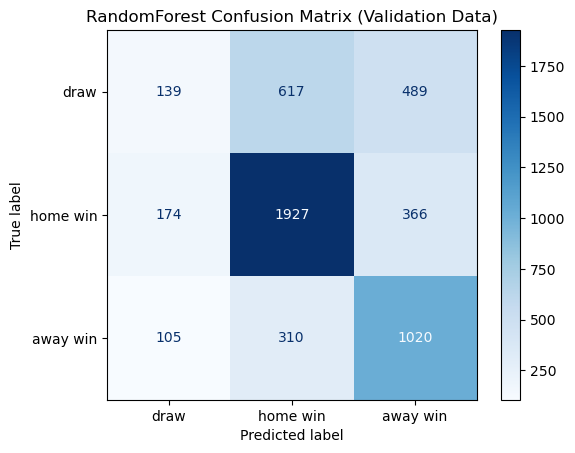

In [48]:
# Plot Confusion Matrix
cm = confusion_matrix(Y_val, val_preds)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['draw', 'home win', 'away win'])
disp2.plot(cmap=plt.cm.Blues)
plt.title("RandomForest Confusion Matrix (Validation Data)")
plt.show()

In [49]:
boost_clf = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=7)

boost_clf.fit(X_train_std, Y_train)

# Predictions on Training and Validation sets
train_preds2 = boost_clf.predict(X_train_std)
val_preds2 = boost_clf.predict(X_val_std)

# Evaluate Accuracy of the model
train_acc2 = accuracy_score(Y_train, train_preds2)
val_acc2 = accuracy_score(Y_val, val_preds2)

print("Training Accuracy: ", train_acc2)
print("Validation Accuracy: ", val_acc2)

Training Accuracy:  0.6295118151129576
Validation Accuracy:  0.6083155236059841


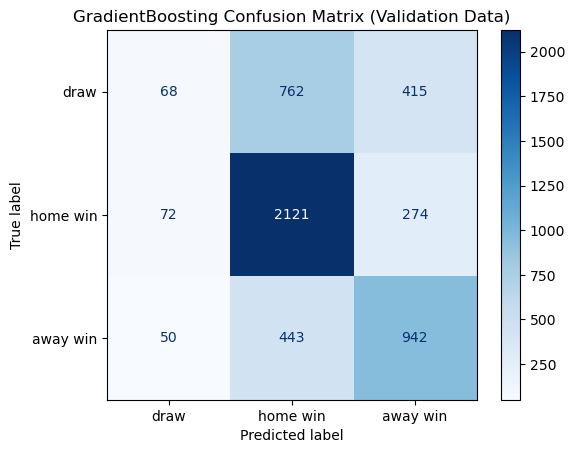

In [50]:
cm2 = confusion_matrix(Y_val, val_preds2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['draw', 'home win', 'away win'])
disp2.plot(cmap=plt.cm.Blues)
plt.title("GradientBoosting Confusion Matrix (Validation Data)")
plt.show()

In [51]:
# Predictions on Test sets
test_preds = rfc_clf.predict(X_test_std)

# Evaluate Accuracy of the model
test_acc = accuracy_score(Y_test, test_preds)

print("Test Accuracy: ", test_acc)

Test Accuracy:  0.6044747081712062


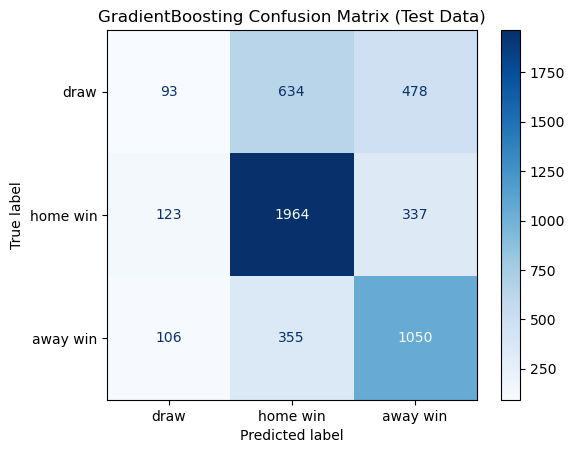

In [52]:
# Test Correlation Matrix for Gradient Boosting (Selected Tree-Based Model)
cm3 = confusion_matrix(Y_test, test_preds)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['draw', 'home win', 'away win'])
disp3.plot(cmap=plt.cm.Blues)
plt.title("GradientBoosting Confusion Matrix (Test Data)")
plt.show()

In [53]:
# Both RandomForest and GradientBoosting Struggle to predict Draw

# Try Probability-based Decision for grad boost

probabilities = boost_clf.predict_proba(X_val_std)


In [54]:
# define the probability based decision function

def prob_decision(probabilities, draw_threshold=0.30):
    predictions=[]

    for p in probabilities:
        p_draw, p_win, p_loss = p

        if p_draw >= draw_threshold:
            predictions.append(0)
        else:
            predictions.append(1 if p_win > p_loss else 2)
    
    return np.array(predictions)

In [55]:
# Get Predictions
val_predictions_probbased = prob_decision(probabilities, draw_threshold=0.33)

In [56]:
# Evaluate the new predictions

print("Prob Based Accuracy: ", accuracy_score(Y_val, val_predictions_probbased))
print(classification_report(Y_val, val_predictions_probbased))

Prob Based Accuracy:  0.5954925199145134
              precision    recall  f1-score   support

           0       0.33      0.20      0.25      1245
           1       0.66      0.80      0.73      2467
           2       0.60      0.58      0.59      1435

    accuracy                           0.60      5147
   macro avg       0.53      0.53      0.52      5147
weighted avg       0.56      0.60      0.57      5147

